Import Required Libraries and Mount Google Drive & Define File Paths to Run Extra Trees ML Algorithm on WESAD Dataset

In [ ]:
# ==============================================================================
# Mount Google Drive & Import Libraries
# ==============================================================================
import os
import joblib
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, balanced_accuracy_score,
    matthews_corrcoef, cohen_kappa_score, log_loss, brier_score_loss,
    roc_curve, precision_recall_curve, auc
)

from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# ==============================================================================
# Define File Paths & Directories
# ==============================================================================
# Set Project Workspace Paths
BASE_DIR = '/content/drive/MyDrive/Aditi/CollegeProject_Stress/WESAD_ExtraTrees'
INPUT_DIR = os.path.join(BASE_DIR, 'InputData')
OUTPUT_FILES_DIR = os.path.join(BASE_DIR, 'OutPutFiles')
OUTPUT_MODEL_DIR = os.path.join(BASE_DIR, 'OutPutModel')

os.makedirs(OUTPUT_FILES_DIR, exist_ok=True)
os.makedirs(OUTPUT_MODEL_DIR, exist_ok=True)

# File Paths
INPUT_CSV_PATH = os.path.join(INPUT_DIR, 'WESAD_FINAL_NSRI_30sec_50overlap_CLEAN.csv')
MODEL_SAVE_PATH = os.path.join(OUTPUT_MODEL_DIR, 'ExtraTreeWESADModel01.pkl')

# Output Report & Metric Paths
TEST_RESULTS_PATH = os.path.join(OUTPUT_FILES_DIR, 'ExtraTreeWesadModelTestResults.csv')
PRED_RESULTS_PATH = os.path.join(OUTPUT_FILES_DIR, 'ExtraTreeWesadModelPredResults.csv')
METRICS_SUMMARY_PATH = os.path.join(OUTPUT_FILES_DIR, 'ExtraTrees_Test_Metrics_Summary.csv')
FEAT_IMPORTANCE_PATH = os.path.join(OUTPUT_FILES_DIR, 'ExtraTrees_Feature_Importance.csv')
CLASS_REPORT_PATH = os.path.join(OUTPUT_FILES_DIR, 'ExtraTrees_Classification_Report.csv')
EVAL_PLOT_PATH = os.path.join(OUTPUT_FILES_DIR, 'ExtraTrees_Evaluation_Dashboard.png')

print("All directories and target paths successfully configured.")

Mounted at /content/drive
All directories and target paths successfully configured.


Data Preprocessing & Feature Extraction

In [ ]:
df = pd.read_csv(INPUT_CSV_PATH)
print(f"Dataset Successfully Loaded: {df.shape[0]} rows, {df.shape[1]} columns")

TARGET_COL = 'stress_target'
METADATA_COLS = [
    'subject', 'window_id', 'window_start_sec', 'window_duration_sec',
    'label', 'target_name', 'Actual_Label', TARGET_COL
]

FEATURE_COLS = [col for col in df.columns if col not in METADATA_COLS]
print(f"Total Model Features: {len(FEATURE_COLS)}")

# Feature and Target matrices
X = df[FEATURE_COLS].copy()
y = df[TARGET_COL].copy()

# Handling edge anomalies / missing values
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.mean())

print(f"Class Ratio:\n{y.value_counts(normalize=True).rename({0: 'Not Target (0)', 1: 'Target (1)'}) * 100}")

Dataset Successfully Loaded: 2878 rows, 24 columns
Total Model Features: 18
Class Ratio:
stress_target
Not Target (0)    77.692842
Target (1)        22.307158
Name: proportion, dtype: float64


Extra Trees Classifier Model Training, Comprehensive Metrics & Visualizations & Save Model Artifact

[SAVED] Extra Trees Model -> /content/drive/MyDrive/Aditi/CollegeProject_Stress/WESAD_ExtraTrees/OutPutModel/ExtraTreeWESADModel01.pkl


,Metric,Score
0,Accuracy,0.9861
1,Balanced Accuracy,0.9743
2,Precision (Target),0.9839
3,Recall / Sensitivity,0.9531
4,Specificity,0.9955
5,F1-Score,0.9683
6,ROC-AUC,0.9975
7,Matthews Corr Coef (MCC),0.9596
8,Cohen Kappa,0.9594
9,Log Loss,0.0729


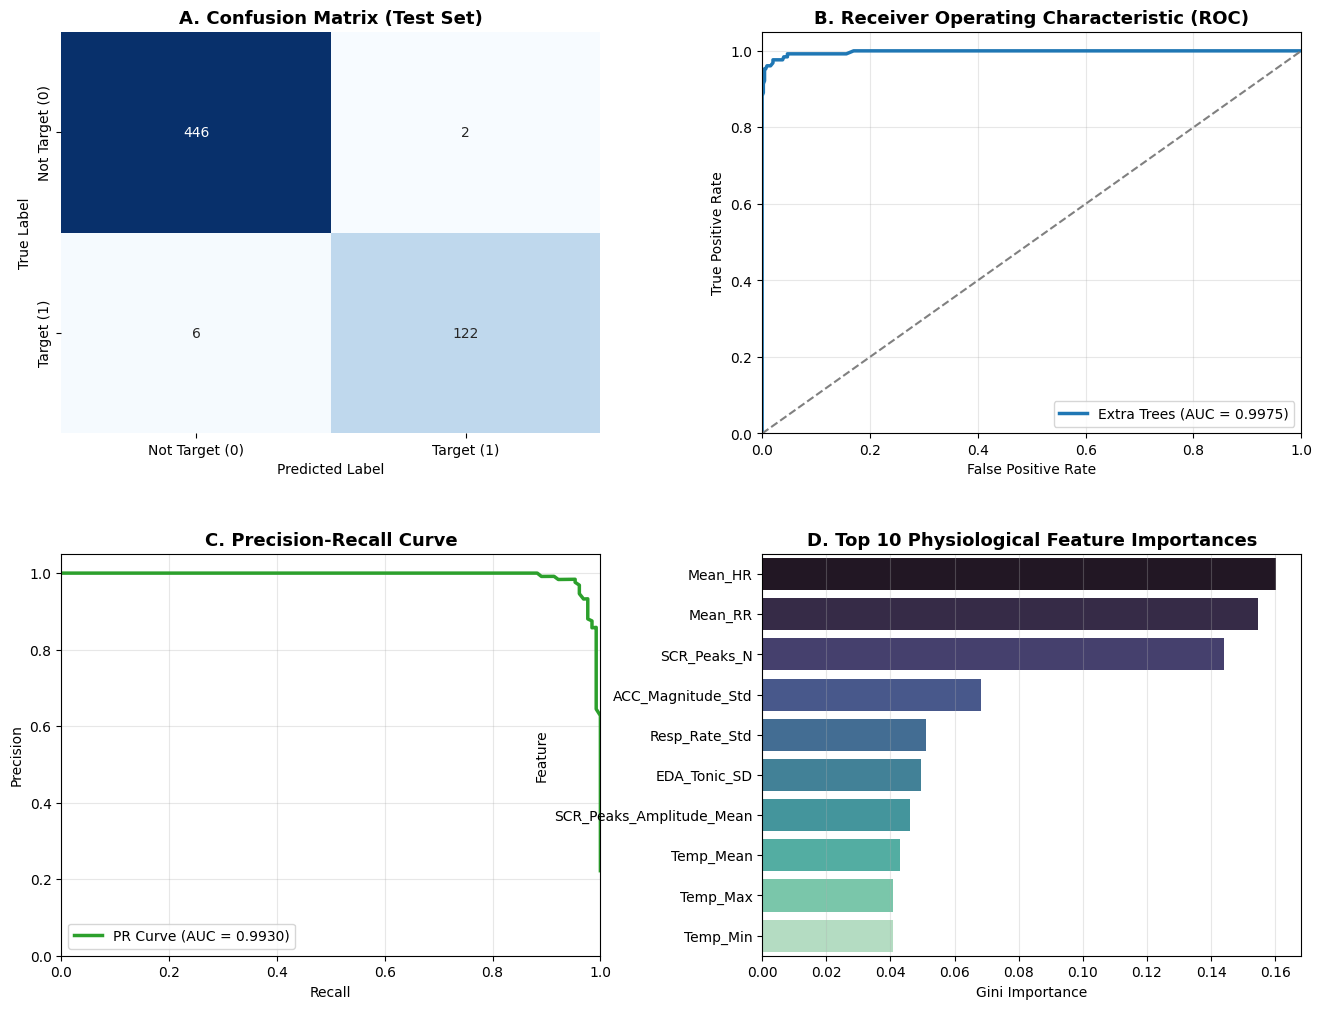

[SAVED] Evaluation Dashboard Plot -> /content/drive/MyDrive/Aditi/CollegeProject_Stress/WESAD_ExtraTrees/OutPutFiles/ExtraTrees_Evaluation_Dashboard.png
Model saved to: /content/drive/MyDrive/Aditi/CollegeProject_Stress/WESAD_ExtraTrees/OutPutModel/ExtraTreeWESADModel01.pkl

--- Test Set Metrics ---
Accuracy:  0.9861
Precision: 0.9839
Recall:    0.9531
F1-Score:  0.9683
ROC-AUC:   0.9975

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99       448
           1       0.98      0.95      0.97       128

    accuracy                           0.99       576
   macro avg       0.99      0.97      0.98       576
weighted avg       0.99      0.99      0.99       576

Test results saved to: /content/drive/MyDrive/Aditi/CollegeProject_Stress/WESAD_ExtraTrees/OutPutFiles/ExtraTreeWesadModelTestResults.csv


In [ ]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, balanced_accuracy_score,
    matthews_corrcoef, cohen_kappa_score, log_loss, brier_score_loss,
    roc_curve, precision_recall_curve, auc
)

# 80/20 Stratified Train-Test Split
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, df.index, test_size=0.20, random_state=42, stratify=y
)

# Instantiate Extra Trees Classifier
extra_trees_model = ExtraTreesClassifier(
    n_estimators=150,
    criterion='gini',
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1,
    bootstrap=False
)

# Train & save model
extra_trees_model.fit(X_train, y_train)
extra_trees_model.feature_names_in_ = np.array(FEATURE_COLS)
joblib.dump(extra_trees_model, MODEL_SAVE_PATH)
print(f"[SAVED] Extra Trees Model -> {MODEL_SAVE_PATH}")

# Predict on Test Split
y_pred = extra_trees_model.predict(X_test)
y_proba = extra_trees_model.predict_proba(X_test)[:, 1]

# Confusion Matrix Elements
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

# 1. Compile Comprehensive Test Metrics
metrics_dict = {
    'Metric': [
        'Accuracy', 'Balanced Accuracy', 'Precision (Target)', 'Recall / Sensitivity',
        'Specificity', 'F1-Score', 'ROC-AUC', 'Matthews Corr Coef (MCC)',
        'Cohen Kappa', 'Log Loss', 'Brier Score'
    ],
    'Score': [
        accuracy_score(y_test, y_pred),
        balanced_accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, zero_division=0),
        recall_score(y_test, y_pred, zero_division=0),
        specificity,
        f1_score(y_test, y_pred, zero_division=0),
        roc_auc_score(y_test, y_proba),
        matthews_corrcoef(y_test, y_pred),
        cohen_kappa_score(y_test, y_pred),
        log_loss(y_test, y_proba),
        brier_score_loss(y_test, y_proba)
    ]
}
metrics_summary_df = pd.DataFrame(metrics_dict)
metrics_summary_df.to_csv(METRICS_SUMMARY_PATH, index=False)
display(metrics_summary_df.round(4))

# 2. Export Classification Report
clf_report = classification_report(y_test, y_pred, target_names=['Not Target (0)', 'Target (1)'], output_dict=True)
clf_report_df = pd.DataFrame(clf_report).transpose()
clf_report_df.to_csv(CLASS_REPORT_PATH)

# 3. Export Feature Importance
feat_imp_df = pd.DataFrame({
    'Feature': FEATURE_COLS,
    'Importance': extra_trees_model.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)
feat_imp_df.to_csv(FEAT_IMPORTANCE_PATH, index=False)

# 4. Save Detailed Test Row Predictions
test_export_df = df.loc[idx_test].copy()
test_export_df['Actual_Label'] = y_test.map({0: 'Not Target', 1: 'Target'})
test_export_df['Predicted_Target'] = y_pred
test_export_df['Predicted_Label'] = pd.Series(y_pred, index=idx_test).map({0: 'Not Target', 1: 'Target'}).values
test_export_df['Stress_Probability'] = np.round(y_proba, 6)
test_export_df['Prediction_Confidence'] = np.round(np.max(extra_trees_model.predict_proba(X_test), axis=1) * 100.0, 2)
test_export_df['Prediction_Status'] = np.where(y_test == y_pred, 'Correct', 'Incorrect')
test_export_df['Model_Used'] = 'Extra Trees'
test_export_df.to_csv(TEST_RESULTS_PATH, index=False)

# ==============================================================================
# 5. Evaluation Dashboard Visualization (4 Panels)
# ==============================================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
plt.subplots_adjust(wspace=0.3, hspace=0.3)

# Panel A: Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0, 0],
            xticklabels=['Not Target (0)', 'Target (1)'],
            yticklabels=['Not Target (0)', 'Target (1)'])
axes[0, 0].set_title('A. Confusion Matrix (Test Set)', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Predicted Label')
axes[0, 0].set_ylabel('True Label')

# Panel B: ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
axes[0, 1].plot(fpr, tpr, color='#1f77b4', lw=2.5, label=f'Extra Trees (AUC = {roc_auc:.4f})')
axes[0, 1].plot([0, 1], [0, 1], color='grey', lw=1.5, linestyle='--')
axes[0, 1].set_xlim([0.0, 1.0])
axes[0, 1].set_ylim([0.0, 1.05])
axes[0, 1].set_title('B. Receiver Operating Characteristic (ROC)', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].legend(loc='lower right')
axes[0, 1].grid(True, alpha=0.3)

# Panel C: Precision-Recall Curve
prec, rec, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(rec, prec)
axes[1, 0].plot(rec, prec, color='#2ca02c', lw=2.5, label=f'PR Curve (AUC = {pr_auc:.4f})')
axes[1, 0].set_title('C. Precision-Recall Curve', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Recall')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].set_xlim([0.0, 1.0])
axes[1, 0].set_ylim([0.0, 1.05])
axes[1, 0].legend(loc='lower left')
axes[1, 0].grid(True, alpha=0.3)

# Panel D: Top 10 Feature Importances
top10_feats = feat_imp_df.head(10)
sns.barplot(data=top10_feats, x='Importance', y='Feature', palette='mako', ax=axes[1, 1])
axes[1, 1].set_title('D. Top 10 Physiological Feature Importances', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Gini Importance')
axes[1, 1].grid(True, alpha=0.3, axis='x')

plt.savefig(EVAL_PLOT_PATH, dpi=300, bbox_inches='tight')
plt.show()
print(f"[SAVED] Evaluation Dashboard Plot -> {EVAL_PLOT_PATH}")


# Save Model with attached feature names schema
extra_trees_model.feature_names_in_ = np.array(FEATURE_COLS)
joblib.dump(extra_trees_model, MODEL_SAVE_PATH)
print(f"Model saved to: {MODEL_SAVE_PATH}")

# Evaluation on Test Split
y_pred = extra_trees_model.predict(X_test)
y_proba = extra_trees_model.predict_proba(X_test)[:, 1]

print("\n--- Test Set Metrics ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Save Test Set Results to OutPutFiles
test_results_df = df.loc[idx_test].copy()
test_results_df["Actual_Label"] = y_test.map({0: "Not Target", 1: "Target"})
test_results_df["Predicted_Target"] = y_pred
test_results_df["Predicted_Label"] = (
    pd.Series(y_pred, index=idx_test).map({0: "Not Target", 1: "Target"}).values
)
test_results_df["Stress_Probability"] = y_proba
test_results_df["Prediction_Confidence"] = (
    np.max(extra_trees_model.predict_proba(X_test), axis=1) * 100.0
)
test_results_df["Prediction_Status"] = np.where(
    y_test == y_pred, "Correct", "Incorrect"
)
test_results_df["Model_Used"] = "Extra Trees"

test_results_df.to_csv(TEST_RESULTS_PATH, index=False)
print(f"Test results saved to: {TEST_RESULTS_PATH}")

Standalone Prediction Function (Inference on Full Dataset)

In [ ]:
# # ==============================================================================
# Cell 4: Standalone Production Predict & Full Evaluation Function
# ==============================================================================
import os
import joblib
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    brier_score_loss,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    log_loss,
    matthews_corrcoef,
    precision_score,
    recall_score,
    roc_auc_score,
)


def execute_wesad_prediction_pipeline(
    input_csv,
    model_path,
    output_pred_csv,
    output_metrics_csv=None,
    output_report_csv=None,
):
  """Self-contained inference and evaluation engine:

  1. Loads serialized model artifact and validates input schema.
  2. Runs batch predictions and computes class probabilities & confidence.
  3. Evaluates full comprehensive performance metrics if ground truth is
  available.
  4. Exports detailed results CSV, metrics summary CSV, and classification
  report CSV.
  """
  if not os.path.exists(model_path):
    raise FileNotFoundError(f"Trained model not found at: {model_path}")
  if not os.path.exists(input_csv):
    raise FileNotFoundError(f"Input dataset not found at: {input_csv}")

  # 1. Load Model & Data
  model = joblib.load(model_path)
  data = pd.read_csv(input_csv)
  print(f"[LOADED] Dataset: {data.shape[0]} rows | Model: {type(model).__name__}")

  # 2. Align Feature Matrix
  expected_features = list(model.feature_names_in_)
  missing_cols = [c for c in expected_features if c not in data.columns]
  if missing_cols:
    raise ValueError(f"Input data is missing required features: {missing_cols}")

  X_mat = (
      data[expected_features]
      .replace([np.inf, -np.inf], np.nan)
      .fillna(data[expected_features].mean())
  )

  # 3. Model Inference
  preds = model.predict(X_mat)
  probas = model.predict_proba(X_mat)
  proba_target = probas[:, 1] if probas.shape[1] > 1 else probas[:, 0]
  confidence = np.max(probas, axis=1) * 100.0

  # 4. Assemble Detailed Predictions DataFrame
  output_df = data.copy()
  output_df["Predicted_Target"] = preds
  output_df["Stress_Probability"] = np.round(proba_target, 6)
  output_df["Prediction_Confidence"] = np.round(confidence, 2)
  output_df["Predicted_Label"] = output_df["Predicted_Target"].map(
      {0: "Not Target", 1: "Target"}
  )
  output_df["Model_Used"] = "Extra Trees"

  # 5. Comprehensive Metric Evaluation (When ground truth exists)
  metrics_df = None
  target_col = "stress_target"

  if target_col in output_df.columns:
    y_true = output_df[target_col].astype(int)
    y_pred = output_df["Predicted_Target"].astype(int)

    output_df["Actual_Label"] = y_true.map({0: "Not Target", 1: "Target"})
    output_df["Prediction_Status"] = np.where(
        y_true == y_pred, "Correct", "Incorrect"
    )

    # Confusion matrix calculations
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    # Build comprehensive metrics suite
    metrics_data = {
        "Metric": [
            "Accuracy",
            "Balanced Accuracy",
            "Precision (Target)",
            "Recall / Sensitivity",
            "Specificity",
            "F1-Score",
            "ROC-AUC",
            "Matthews Corr Coef (MCC)",
            "Cohen Kappa",
            "Log Loss",
            "Brier Score",
            "Total Samples Evaluated",
            "Correct Predictions",
            "Incorrect Predictions",
            "Mean Prediction Confidence (%)",
        ],
        "Score": [
            accuracy_score(y_true, y_pred),
            balanced_accuracy_score(y_true, y_pred),
            precision_score(y_true, y_pred, zero_division=0),
            recall_score(y_true, y_pred, zero_division=0),
            specificity,
            f1_score(y_true, y_pred, zero_division=0),
            roc_auc_score(y_true, proba_target),
            matthews_corrcoef(y_true, y_pred),
            cohen_kappa_score(y_true, y_pred),
            log_loss(y_true, proba_target),
            brier_score_loss(y_true, proba_target),
            len(y_true),
            int((y_true == y_pred).sum()),
            int((y_true != y_pred).sum()),
            np.mean(confidence),
        ],
    }
    metrics_df = pd.DataFrame(metrics_data)

    # Generate classification report
    clf_report_dict = classification_report(
        y_true,
        y_pred,
        target_names=["Not Target (0)", "Target (1)"],
        output_dict=True,
    )
    clf_report_df = pd.DataFrame(clf_report_dict).transpose()

    # Display results to console
    print("\n" + "=" * 60)
    print("      COMPREHENSIVE PREDICTION EVALUATION METRICS")
    print("=" * 60)
    display(metrics_df.round(4))

    print("\n" + "=" * 60)
    print("             CLASSIFICATION REPORT SUMMARY")
    print("=" * 60)
    display(clf_report_df.round(4))

    # Optional CSV Exports for Metrics and Reports
    if output_metrics_csv:
      metrics_df.to_csv(output_metrics_csv, index=False)
      print(f"[EXPORTED] Metrics Summary -> {output_metrics_csv}")

    if output_report_csv:
      clf_report_df.to_csv(output_report_csv)
      print(f"[EXPORTED] Classification Report -> {output_report_csv}")

  else:
    print(
        f"\n[INFO] '{target_col}' not found in dataset; generated predictions"
        " only."
    )

  # 6. Save Detailed Predictions CSV
  output_df.to_csv(output_pred_csv, index=False)
  print(f"[EXPORTED] Full Prediction Report -> {output_pred_csv}")

  return output_df, metrics_df


# ==============================================================================
# Execute Standalone Prediction & Evaluation Pipeline
# ==============================================================================
FULL_PRED_METRICS_PATH = os.path.join(
    OUTPUT_FILES_DIR, "ExtraTrees_FullPred_Metrics_Summary.csv"
)
FULL_PRED_REPORT_PATH = os.path.join(
    OUTPUT_FILES_DIR, "ExtraTrees_FullPred_Classification_Report.csv"
)

full_inference_df, full_metrics_df = execute_wesad_prediction_pipeline(
    input_csv=INPUT_CSV_PATH,
    model_path=MODEL_SAVE_PATH,
    output_pred_csv=PRED_RESULTS_PATH,
    output_metrics_csv=FULL_PRED_METRICS_PATH,
    output_report_csv=FULL_PRED_REPORT_PATH,
)

[LOADED] Dataset: 2878 rows | Model: ExtraTreesClassifier

      COMPREHENSIVE PREDICTION EVALUATION METRICS


,Metric,Score
0,Accuracy,0.9972
1,Balanced Accuracy,0.9949
2,Precision (Target),0.9969
3,Recall / Sensitivity,0.9907
4,Specificity,0.9991
5,F1-Score,0.9938
6,ROC-AUC,0.9999
7,Matthews Corr Coef (MCC),0.9920
8,Cohen Kappa,0.9920
9,Log Loss,0.0146



             CLASSIFICATION REPORT SUMMARY


,precision,recall,f1-score,support
Not Target (0),0.9973,0.9991,0.9982,2236.0000
Target (1),0.9969,0.9907,0.9938,642.0000
accuracy,0.9972,0.9972,0.9972,0.9972
macro avg,0.9971,0.9949,0.9960,2878.0000
weighted avg,0.9972,0.9972,0.9972,2878.0000


[EXPORTED] Metrics Summary -> /content/drive/MyDrive/Aditi/CollegeProject_Stress/WESAD_ExtraTrees/OutPutFiles/ExtraTrees_FullPred_Metrics_Summary.csv
[EXPORTED] Classification Report -> /content/drive/MyDrive/Aditi/CollegeProject_Stress/WESAD_ExtraTrees/OutPutFiles/ExtraTrees_FullPred_Classification_Report.csv
[EXPORTED] Full Prediction Report -> /content/drive/MyDrive/Aditi/CollegeProject_Stress/WESAD_ExtraTrees/OutPutFiles/ExtraTreeWesadModelPredResults.csv
